In [1]:
# Run garbage collection
import gc
gc.collect()

0

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import logging
import wfdb
import ast
import torch
import seaborn as sns
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, confusion_matrix
from tabulate import tabulate
import os
from collections import Counter

In [3]:
path_load = 'data_source'

X_train = np.load(os.path.join(path_load, 'data_sourceY_train.npy'))
y_train = pd.read_csv(os.path.join(path_load, 'data_sourceZ_train.csv'))
y_train = y_train.drop(columns=['ecg_id'])

X_test = np.load(os.path.join(path_load, 'data_sourceY_test.npy'))
y_test = pd.read_csv(os.path.join(path_load, 'data_sourceZ_test.csv'))
y_test = y_test.drop(columns=['ecg_id'])

X_val = np.load(os.path.join(path_load, 'data_sourceY_valid.npy'))
y_val = pd.read_csv(os.path.join(path_load, 'data_sourceZ_valid.csv'))
y_val = y_val.drop(columns=['ecg_id'])

table = [
    ["X_train", X_train.shape],
    ["y_train", y_train.shape],
    ["X_test", X_test.shape],
    ["y_test", y_test.shape],
    ["X_val", X_val.shape],
    ["y_val", y_val.shape],
]

print(tabulate(table, headers=["Dataset", "Shape"], tablefmt="grid"))

+-----------+-------------------+
| Dataset   | Shape             |
+===========+===================+
| X_train   | (17418, 1000, 12) |
+-----------+-------------------+
| y_train   | (17418, 5)        |
+-----------+-------------------+
| X_test    | (2198, 1000, 12)  |
+-----------+-------------------+
| y_test    | (2198, 5)         |
+-----------+-------------------+
| X_val     | (2183, 1000, 12)  |
+-----------+-------------------+
| y_val     | (2183, 5)         |
+-----------+-------------------+


In [4]:
import numpy as np
from pyts.image import RecurrencePlot, MarkovTransitionField, GramianAngularField
import os

# Parameters
batch_size = 32
selected_channels = [1, 6]  # II, V1, V6
output_dir = "transformed_batches"
os.makedirs(output_dir, exist_ok=True)
output_dir_train = os.path.join(output_dir, 'train')
output_dir_test = os.path.join(output_dir, 'test')
output_dir_val = os.path.join(output_dir, 'val')
os.makedirs(output_dir_train, exist_ok=True)
os.makedirs(output_dir_test, exist_ok=True)
os.makedirs(output_dir_val, exist_ok=True)
# Load your full data once (assuming shape: B, T, C)
data_train = X_train[:, :, selected_channels]  # now shape (17418, 1000, 3)
data_test = X_test[:, :, selected_channels]  # now shape (2198, 1000, 3)
data_val = X_val[:, :, selected_channels]  # now shape (2183, 1000, 3)

n_samples_train, time_len, n_channels = data_train.shape
n_samples_test, time_len, n_channels = data_test.shape
n_samples_val, time_len, n_channels = data_val.shape

# Prepare transformers
rp = RecurrencePlot(threshold='point', percentage=20)
mtf = MarkovTransitionField(n_bins=8)
gaf = GramianAngularField(method='summation')

def transform_batch(X_batch):
    B, T, C = X_batch.shape
    X_rp  = np.zeros((B, C, T, T), dtype=np.float16)
    X_mtf = np.zeros((B, C, T, T), dtype=np.float16)
    X_gaf = np.zeros((B, C, T, T), dtype=np.float16)
    
    for b in range(B):
        for c in range(C):
            ts = X_batch[b, :, c].reshape(1, -1)
            X_rp[b, c] = rp.fit_transform(ts)[0]
            X_mtf[b, c] = mtf.fit_transform(ts)[0]
            X_gaf[b, c] = gaf.fit_transform(ts)[0]
    
    return X_rp, X_mtf, X_gaf

def transform_and_save(data, n_samples, batch_size, output_dir):
    for i in range(0, n_samples, batch_size):
        batch_data = data[i:i + batch_size]
        X_rp, X_mtf, X_gaf = transform_batch(batch_data)

        np.save(f"{output_dir}/rp_batch_{i//batch_size}.npy", X_rp)
        np.save(f"{output_dir}/mtf_batch_{i//batch_size}.npy", X_mtf)
        np.save(f"{output_dir}/gaf_batch_{i//batch_size}.npy", X_gaf)
        del batch_data, X_rp, X_mtf, X_gaf
        gc.collect()
        print(f"Saved batch {i//batch_size + 1} of {n_samples // batch_size + 1} -> path: {output_dir}", end='\r')
    
# Process in mini-batches for training data
transform_and_save(data_train, n_samples_train, batch_size, output_dir_train)
transform_and_save(data_test, n_samples_test, batch_size, output_dir_test)
transform_and_save(data_val, n_samples_val, batch_size, output_dir_val)

In [1]:
import torch
from torch.utils.data import Dataset
import numpy as np
import pandas as pd
import os
from torch.utils.data import TensorDataset, DataLoader
class ECGTransformedDataset(Dataset):
    def __init__(self, rp_dir, mtf_dir, gaf_dir, labels_path, transform=None):
        """
        rp_dir, mtf_dir, gaf_dir: folder paths containing rp_batch_*.npy, mtf_batch_*.npy, gaf_batch_*.npy
        labels_path: path to .csv or .npy label file with labels aligned to all samples
        transform: optional transforms to apply on samples
        """
        self.rp_dir = rp_dir
        self.mtf_dir = mtf_dir
        self.gaf_dir = gaf_dir
        self.transform = transform
        
        # Load labels
        if labels_path.endswith('.npy'):
            self.labels = np.load(labels_path)
        else:
            import pandas as pd
            df = pd.read_csv(labels_path)
            # Assuming labels start from second column (remove ID if exists)
            self.labels = df.iloc[:, 1:].values.astype(np.float32)

        # List batch files and sort to keep order
        self.rp_files = sorted([f for f in os.listdir(rp_dir) if f.startswith('rp_batch_') and f.endswith('.npy')],
                               key=lambda x: int(x.split('_')[-1].split('.')[0]))
        self.mtf_files = sorted([f for f in os.listdir(mtf_dir) if f.startswith('mtf_batch_') and f.endswith('.npy')],
                                key=lambda x: int(x.split('_')[-1].split('.')[0]))
        self.gaf_files = sorted([f for f in os.listdir(gaf_dir) if f.startswith('gaf_batch_') and f.endswith('.npy')],
                                key=lambda x: int(x.split('_')[-1].split('.')[0]))

        # Cache batch sizes to map index -> batch + sample_in_batch
        self.batch_sizes = []
        for f in self.rp_files:
            path = os.path.join(rp_dir, f)
            batch_data = np.load(path, mmap_mode='r')
            self.batch_sizes.append(batch_data.shape[0])
        self.cum_batch_sizes = np.cumsum(self.batch_sizes)

    def __len__(self):
        return self.labels.shape[0]

    def __getitem__(self, idx):
        # Find which batch file idx belongs to
        batch_idx = np.searchsorted(self.cum_batch_sizes, idx, side='right')
        sample_idx = idx
        if batch_idx > 0:
            sample_idx = idx - self.cum_batch_sizes[batch_idx-1]

        # Load the sample from batch files (using mmap to avoid full load)
        rp_path = os.path.join(self.rp_dir, self.rp_files[batch_idx])
        mtf_path = os.path.join(self.mtf_dir, self.mtf_files[batch_idx])
        gaf_path = os.path.join(self.gaf_dir, self.gaf_files[batch_idx])

        rp_batch = np.load(rp_path, mmap_mode='r')
        mtf_batch = np.load(mtf_path, mmap_mode='r')
        gaf_batch = np.load(gaf_path, mmap_mode='r')

        rp_sample = rp_batch[sample_idx]
        mtf_sample = mtf_batch[sample_idx]
        gaf_sample = gaf_batch[sample_idx]

        # Convert to torch tensors
        rp_sample = torch.tensor(rp_sample, dtype=torch.float32)
        mtf_sample = torch.tensor(mtf_sample, dtype=torch.float32)
        gaf_sample = torch.tensor(gaf_sample, dtype=torch.float32)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)

        if self.transform:
            rp_sample = self.transform(rp_sample)
            mtf_sample = self.transform(mtf_sample)
            gaf_sample = self.transform(gaf_sample)

        return {'rp': rp_sample, 'mtf': mtf_sample, 'gaf': gaf_sample, 'label': label}

output_dir = "transformed_batches"
output_dir_train = os.path.join(output_dir, 'train')
output_dir_test = os.path.join(output_dir, 'test')
output_dir_val = os.path.join(output_dir, 'val')

batch_size = 8  
train_dataset = ECGTransformedDataset(output_dir_train, 
                                      output_dir_train, 
                                      output_dir_train,
                                      'data_source/data_sourceZ_train.csv')
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
test_dataset = ECGTransformedDataset(output_dir_test, 
                                     output_dir_test, 
                                     output_dir_test,
                                     'data_source/data_sourceZ_test.csv')
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=4)
val_dataset = ECGTransformedDataset(output_dir_val, 
                                     output_dir_val, 
                                     output_dir_val,
                                     'data_source/data_sourceZ_valid.csv')
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)


In [2]:
import torch.nn as nn

class CNN_GRU(nn.Module):
    def __init__(self, input_channels=2, hidden_size=32, num_classes=5):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(input_channels, 16, kernel_size=3, padding=1),  # fewer filters
            nn.ReLU(),
            nn.MaxPool2d(2),  # 1000->500
            nn.Conv2d(16, 32, kernel_size=3, padding=1),  # fewer filters
            nn.ReLU(),
            nn.MaxPool2d(2),  # 500->250
        )
        # After CNN, output shape: (batch, 32, 250, 250)

        # Reduce features from 32*250=8000 to 128 (smaller than before)
        self.feature_reduce = nn.Linear(32 * 250, 128)
        
        self.gru = nn.GRU(input_size=128, hidden_size=hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        # x: (batch, channels=2, 1000, 1000)
        x = self.cnn(x)  # (batch, 32, 250, 250)
        batch_size, ch, h, w = x.size()  # ch=32, h=250, w=250
        
        # Reshape to (batch, seq_len=h=250, features=w*ch=250*32=8000)
        x = x.reshape(batch_size, ch, h * w).permute(0, 2, 1)  # (batch, 62500, 32)
        
        # Reshape to (batch, seq_len=250, features=8000)
        x = x.reshape(batch_size, h, w * ch)  # (batch, 250, 8000)
        
        # Feature reduction to 128 dims
        x = self.feature_reduce(x)  # (batch, 250, 128)
        
        out, _ = self.gru(x)  # (batch, 250, hidden_size)
        out = out[:, -1, :]   # (batch, hidden_size)
        out = self.fc(out)    # (batch, num_classes)
        return out


In [3]:
import torch.optim as optim

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Models per modality
model_rp = CNN_GRU().to(device)
model_mtf = CNN_GRU().to(device)
model_gaf = CNN_GRU().to(device)

optim_rp = optim.Adam(model_rp.parameters(), lr=1e-3)
optim_mtf = optim.Adam(model_mtf.parameters(), lr=1e-3)
optim_gaf = optim.Adam(model_gaf.parameters(), lr=1e-3)

criterion = nn.BCEWithLogitsLoss()


Epoch 1/10 - Train Loss: 0.5131, Val Loss: 0.4894
Epoch 2/10 - Train Loss: 0.4781, Val Loss: 0.4771
Epoch 3/10 - Train Loss: 0.4618, Val Loss: 0.4680
Epoch 4/10 - Train Loss: 0.4501, Val Loss: 0.4840
Epoch 5/10 - Train Loss: 0.4410, Val Loss: 0.4725
Epoch 6/10 - Train Loss: 0.4331, Val Loss: 0.4770
Epoch 7/10 - Train Loss: 0.4208, Val Loss: 0.4907
Epoch 8/10 - Train Loss: 0.4065, Val Loss: 0.4894
Epoch 9/10 - Train Loss: 0.3883, Val Loss: 0.5007
Epoch 10/10 - Train Loss: 0.3750, Val Loss: 0.5091


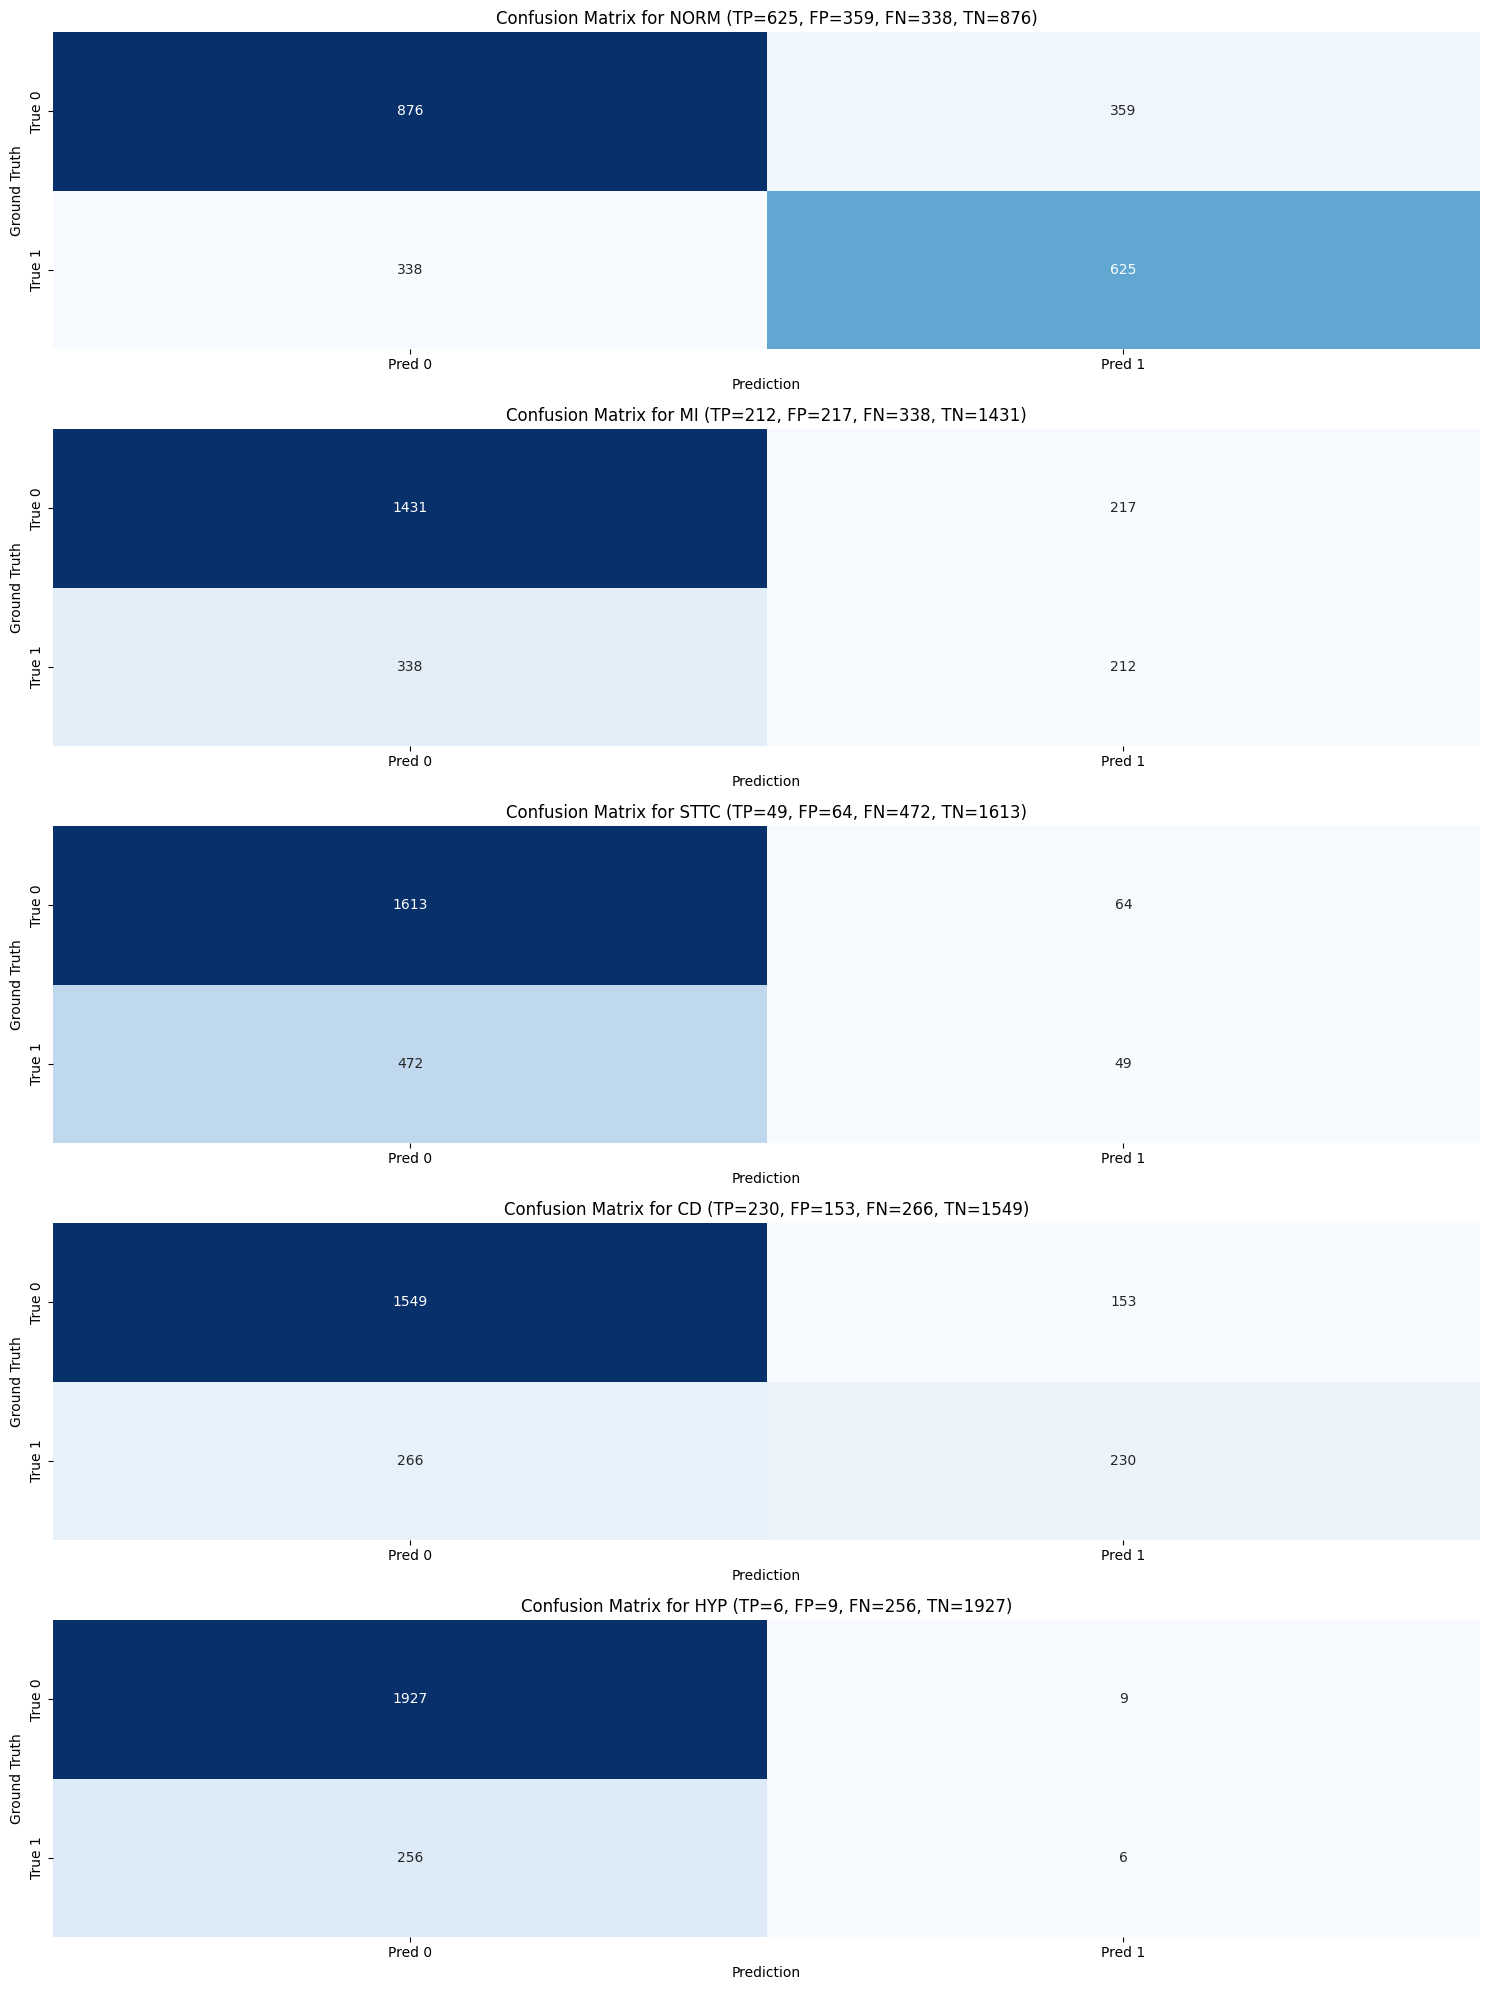

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import multilabel_confusion_matrix

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assume these are defined:
# model_rp, model_mtf, model_gaf
# train_loader, val_loader, test_loader
# criterion = torch.nn.BCEWithLogitsLoss()
# optimizer_rp, optimizer_mtf, optimizer_gaf

def train_epoch_latefusion(train_loader):
    model_rp.train()
    model_mtf.train()
    model_gaf.train()

    total_loss = 0
    for batch in train_loader:
        rp = batch['rp'].to(device)
        mtf = batch['mtf'].to(device)
        gaf = batch['gaf'].to(device)
        labels = batch['label'].to(device)

        optim_rp.zero_grad()
        optim_mtf.zero_grad()
        optim_gaf.zero_grad()

        out_rp = model_rp(rp)
        out_mtf = model_mtf(mtf)
        out_gaf = model_gaf(gaf)

        out = (out_rp + out_mtf + out_gaf) / 3
        loss = criterion(out, labels)

        loss.backward()
        optim_rp.step()
        optim_mtf.step()
        optim_gaf.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    return avg_loss


def validate_epoch_latefusion(val_loader):
    model_rp.eval()
    model_mtf.eval()
    model_gaf.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_loader:
            rp = batch['rp'].to(device)
            mtf = batch['mtf'].to(device)
            gaf = batch['gaf'].to(device)
            labels = batch['label'].to(device)

            out_rp = model_rp(rp)
            out_mtf = model_mtf(mtf)
            out_gaf = model_gaf(gaf)
            out = (out_rp + out_mtf + out_gaf) / 3

            loss = criterion(out, labels)
            total_loss += loss.item()

            preds = torch.sigmoid(out).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())

    avg_loss = total_loss / len(val_loader)
    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    return avg_loss, all_preds, all_labels


def test_epoch_latefusion(test_loader, threshold=0.5):
    model_rp.eval()
    model_mtf.eval()
    model_gaf.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            rp = batch['rp'].to(device)
            mtf = batch['mtf'].to(device)
            gaf = batch['gaf'].to(device)
            labels = batch['label'].to(device)

            out_rp = model_rp(rp)
            out_mtf = model_mtf(mtf)
            out_gaf = model_gaf(gaf)
            out = (out_rp + out_mtf + out_gaf) / 3

            preds = torch.sigmoid(out).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    all_preds_bin = (all_preds >= threshold).astype(int)
    return all_preds_bin, all_labels


def plot_multilabel_confusion_matrix(y_true, y_pred, class_names=None):
    cm = multilabel_confusion_matrix(y_true, y_pred)
    n_classes = cm.shape[0]

    plt.figure(figsize=(15, 4 * n_classes))
    for i in range(n_classes):
        tn, fp, fn, tp = cm[i].ravel()
        ax = plt.subplot(n_classes, 1, i+1)
        sns.heatmap(cm[i], annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'], ax=ax)
        ax.set_xlabel('Prediction')
        ax.set_ylabel('Ground Truth')
        title = class_names[i] if class_names else f'Class {i}'
        ax.set_title(f'Confusion Matrix for {title} (TP={tp}, FP={fp}, FN={fn}, TN={tn})')
    plt.tight_layout()
    plt.show()


# Training loop
num_epochs = 10
class_names = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
torch.cuda.empty_cache()
for epoch in range(num_epochs):
    train_loss = train_epoch_latefusion(train_loader)
    val_loss, val_preds, val_labels = validate_epoch_latefusion(val_loader)
    print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

# Testing + Confusion Matrix
test_preds, test_labels = test_epoch_latefusion(test_loader)
plot_multilabel_confusion_matrix(test_labels, test_preds, class_names=class_names)